<small><font color=gray>Авторы ноутбука: Олег Мельников, Кирилл Быков, Алексей Болдырев, Максим Карпов, Юрий Саночкин ©2026 </font></small><hr style="margin:0;background-color:silver">

**[<font size=6>🪐Venus+Mars</font>](https://www.kaggle.com/t/022c879ccb9a45ce9a80c46225c8627e)**.

Решение:
### Суворов Александр

In [1]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install -U kaggle  # upgrade пакет kaggle (чтобы избежать предупреждения)

In [3]:
!mkdir -p ~/.kaggle                               # папка .kaggle должна содержать kaggle.json для исполняемого файла kaggle, чтобы правильно аутентифицировать вас в Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json  # Сначала загрузите kaggle.json из kaggle.com (на странице учетной записи) и поместите его в корень подключенного Google Диска
!chmod 600 ~/.kaggle/kaggle.json                  # предоставить только владельцу полный доступ для чтения/записи к файлу kaggle.json
!kaggle config set -n competition -v june-26-hse-bi-venus-mars # установите контекст конкурса для следующих нескольких вызовов API kaggle. !kaggle config view - отображает текущие настройки
!kaggle competitions download                     # загрузите набор данных соревнования в виде zip-файла
!unzip -oq *.zip                                   # набор данных с kaggle копируется в виде единого файла, который необходимо распаковать
!kaggle competitions leaderboard --show           # напечатать public leaderboard


# добавил q параметр чтобы не печатало все файлы))

- competition is now set to: june-26-hse-bi-venus-mars
Using competition: june-26-hse-bi-venus-mars
100% 35.0M/35.0M [00:00<00:00, 136MB/s]

Using competition: june-26-hse-bi-venus-mars
Next Page Token = CfDJ8Ih_VxHsLwdJhHStLnSaLO97Z6qvhupgUsvhUTYRikqFrX3aLyxmvI7FBUwfonF3oyuq3h2ktG50RHJuWdwpo7w
  teamId  teamName                     submissionDate              score    
--------  ---------------------------  --------------------------  -------  
16368316  Воронова Юлия                2026-06-18 21:56:31.270000  0.98400  
16242636  Dmitrii Belousov             2026-06-18 18:52:55.430000  0.97880  
16375049  Савелий Салюков              2026-06-18 18:12:06.356000  0.97880  
16382208  Марк Емцов                   2026-06-18 19:15:36.390000  0.97040  
16325190  Трескин Владислав Сергеевич  2026-06-13 11:54:10.366000  0.96960  
16303628  Maksim Romanov               2026-06-18 22:23:40.523000  0.96760  
16374794  Pankova Zlata                2026-06-18 23:48:18.826000  0.96680  
16243219  L

Смотрите [больше](https://nvidia.custhelp.com/app/answers/detail/a_id/3751/~/useful-nvidia-smi-queries) про NVIDIA GPU статистику. Тестируйте свой код в бесплатном Colab. В нем используется графический процессор Tesla T4 или TPU v2-8.

In [4]:
!nvidia-smi --query-gpu=gpu_name,memory.total,memory.free,memory.used --format=csv

name, memory.total [MiB], memory.free [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 14913 MiB, 0 MiB


In [5]:
%%time
%%capture
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS
IS.ast_node_interactivity = "all"
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id')

class Timer():
    def __init__(self, lim=60*5):
        self.t0 = time.time()
        self.lim = lim
        print(f'⏳ начался. У вас есть {lim} сек. Удачи!')

    def ShowTime(self):
        elapsed = time.time() - self.t0
        msg = f'Время выполнения {elapsed:.0f} сек.'
        print(
            f'\033[91m\033[1m{msg} > {self.lim} sec limit!!!\033[0m'
            if elapsed > self.lim
            else msg
        )

np.set_printoptions(linewidth=100, precision=2, edgeitems=5, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

tDIR, sDIR = 'train/', 'test/'
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # округляет значения до 2 знаков после точки

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60*5): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ начался. У вас есть {lim} сек. Удачи!')
  def ShowTime(self):
    msg = f'Время выполнения {time.time()-self.t0:.0f} сек.'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=5, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)
tDIR, sDIR = 'train/', 'test/'

CPU times: user 4.52 s, sys: 534 ms, total: 5.05 s
Wall time: 6.75 s


Примеры изображений женского пола

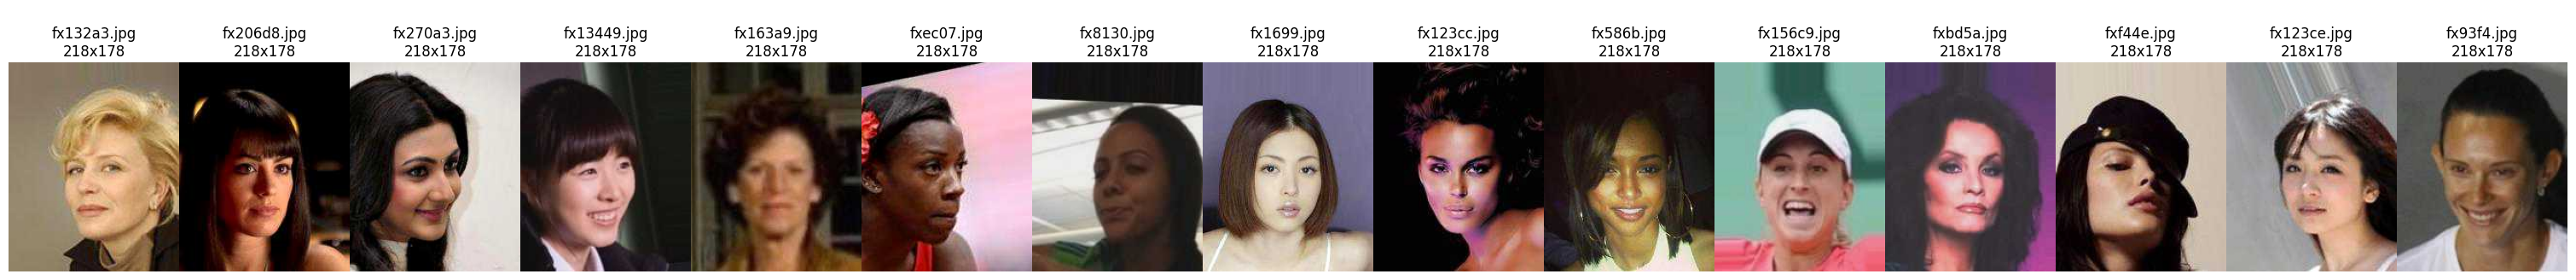

In [6]:
n, fig = 15, plt.figure(figsize=(30,10));
for i, f in enumerate(np.random.RandomState(0).choice(os.listdir(tDIR+'female/'), n)):
  ax = plt.subplot(1, n, i + 1)
  img = plt.imread(tDIR+'female/'+f);
  _ = ax.set_title(f'\n{f}\n{img.shape[0]}x{img.shape[1]}');
  _ = plt.axis('off');   _ = plt.tight_layout(pad=0);   _ = plt.imshow(img);

Примеры изображений мужского пола

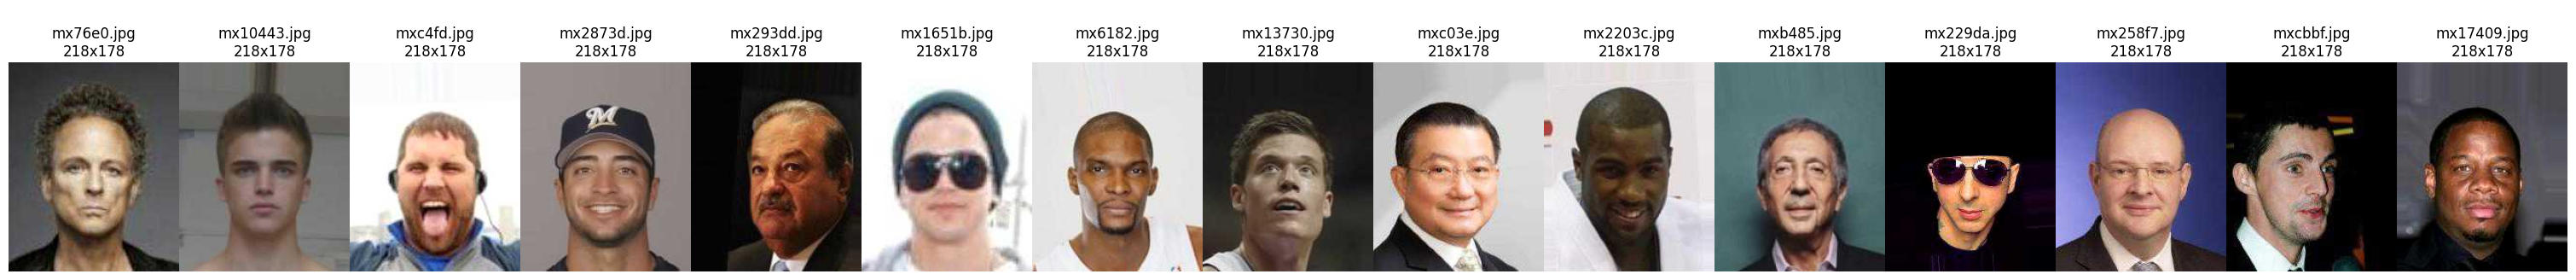

In [7]:
n, fig = 15, plt.figure(figsize=(30,10));
for i, f in enumerate(np.random.RandomState(0).choice(os.listdir(tDIR+'male/'), n)):
  ax = plt.subplot(1, n, i + 1)
  img = plt.imread(tDIR+'male/'+f);
  _ = ax.set_title(f'\n{f}\n{img.shape[0]}x{img.shape[1]}');
  _ = plt.axis('off');   _ = plt.tight_layout(pad=0);   _ = plt.imshow(img);

# Давайте писать код

Сразу скажу, я сиджел над ноутбуком 4 часа, я не понимаю как у меня в посылке 92 качество, если у меня на test 99, на val 98 где то.
Сразу скажу я решил написать этот ноутбке на TF, и забегая вперед, он оказался очень простым и удобным.

In [59]:
tmr = Timer()

⏳ начался. У вас есть 300 сек. Удачи!


In [76]:
mixed_precision.set_global_policy("mixed_float16") # веса будем держать в floaf16

Mixed precision policy: <DTypePolicy "mixed_float16">


In [61]:
IMG_SIZE = (224, 224)  # это размеры входа для resNet 50
BATCH_SIZE = 128
EPOCHS_HEAD = 18
EPOCHS_FINE = 16
# и да, упрекайте меня сколько хотите, но я знаю что констатны в питоне пишутся КАПСОМ

train_dir = "train"
test_dir = "test"

In [62]:
# здесь у нас специальная функция для подгрузки, сами про нее писали

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 5000 files belonging to 2 classes.
Using 4000 files for training.
Found 5000 files belonging to 2 classes.
Using 1000 files for validation.
['female', 'male']


In [63]:
AUTOTUNE = tf.data.AUTOTUNE
# сделаем авто подгрузку весов

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [64]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomContrast(0.08, seed=SEED),
], name="data_augmentation")

# это блок для аугментации наших картинок, ничего слигком сложного не далею

Я пробывал кучу моделей, и кучу архитектур, но в итоге остановился на ResNet50, она оказалось почему то очень быстро и самое главное !!! стабильной во время обучения. Так же сделаем поверх нее не супер сложный mlp голову, и будем в самом конце предсказывать P(male) P(female) через softmax.
Так же я использую активацию SiLU (он же switch).

In [65]:
base_model = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)


base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = layers.Lambda(
    keras.applications.resnet50.preprocess_input,
    name="resnet50_preprocessing"
)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation=None)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("swish")(x)
x = layers.Dropout(0.30)(x)

x = layers.Dense(128, activation=None)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("swish")(x)
x = layers.Dropout(0.20)(x)

outputs = layers.Dense(2, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs)

красивый саммари

In [66]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocessing (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,705,282 (94.24 MB)

 Trainable params: 1,116,290 (4.26 MB)

 Non-trainable params: 23,588,992 (89.98 MB)

Так же важно сказать, что я использую интересный подход, для того чтобы обеспечить стабильность обучения я разделяют обучение на два этапа:
1. Head
2. Fine (от слова fine tuning),

чтобы сначала с замороженными весами resnet50 обучить голову классификации, а потом более аккуратно дообучить модель с уже размороженными несколькими верхними слоями resnet'а
Так что не удивляйтесь))
Так же скажу что не использую sheduler (так как мало эпох сравнительно, и без него рабоатет тоже норм)
+ не использую early stoppong (он скорее мешал мне в моих запусках)

In [67]:
# и да, блин это удобно писать функции в кучу строк, так правда удобно, это не ГПТ
# сами попробуйте, понравиться
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD
)

Epoch 1/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 746ms/step - accuracy: 0.8618 - loss: 0.3338 - val_accuracy: 0.9590 - val_loss: 0.1253
Epoch 2/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.9220 - loss: 0.1920 - val_accuracy: 0.9350 - val_loss: 0.1798
Epoch 3/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.9410 - loss: 0.1489 - val_accuracy: 0.9840 - val_loss: 0.0756
Epoch 4/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.9572 - loss: 0.1163 - val_accuracy: 0.9740 - val_loss: 0.0998
Epoch 5/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9675 - loss: 0.0879 - val_accuracy: 0.9870 - val_loss: 0.0586
Epoch 6/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.9695 - loss: 0.0818 - val_accuracy: 0.9860 - val_loss: 0.0596
Epoch 7/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9780 - loss: 0.0629 - val_accuracy: 0.9800 - val_loss: 0.0715
Epoch 8/18
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.9803 - loss: 0.0515 - val_accuracy: 0

In [68]:
base_model.trainable = True

for layer in base_model.layers[:-5]:
    layer.trainable = False

# размораживаем веса

In [69]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocessing (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,937,868 (102.76 MB)

 Trainable params: 2,171,010 (8.28 MB)

 Non-trainable params: 22,534,272 (85.96 MB)

 Optimizer params: 2,232,586 (8.52 MB)

In [70]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=3e-5,
        weight_decay=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE
)
# обучаем теперь второй раз

Epoch 1/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 746ms/step - accuracy: 0.9942 - loss: 0.0153 - val_accuracy: 0.9880 - val_loss: 0.0745
Epoch 2/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.9970 - loss: 0.0115 - val_accuracy: 0.9850 - val_loss: 0.0912
Epoch 3/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.9977 - loss: 0.0086 - val_accuracy: 0.9850 - val_loss: 0.0873
Epoch 4/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.9965 - loss: 0.0102 - val_accuracy: 0.9800 - val_loss: 0.1062
Epoch 5/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9995 - loss: 0.0053 - val_accuracy: 0.9860 - val_loss: 0.0824
Epoch 6/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9995 - loss: 0.0055 - val_accuracy: 0.9860 - val_loss: 0.0878
Epoch 7/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.9987 - loss: 0.0053 - val_accuracy: 0.9840 - val_loss: 0.0905
Epoch 8/16
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.9995 - loss: 0.0050 - val_accuracy: 0

In [71]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels=None,
    label_mode=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

file_paths = test_ds.file_paths

test_ds = test_ds.prefetch(AUTOTUNE)

Found 5000 files.


In [72]:
probs = model.predict(test_ds)
preds = np.argmax(probs, axis=1)

print(preds[:10])

40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step
[1 0 0 1 1 1 1 1 1 0]


В итоге делаем предсказание для test, и записываем это в csv файл, в формате который вы говорили

In [73]:
ids = [os.path.splitext(os.path.basename(path))[0] for path in file_paths]
submission = pd.DataFrame({
    "id": ids,
    "y": preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,y
0,x10a06,1
1,x10a2d,0
...,...,...
3,x10a6e,1
4,x10a85,1


In [74]:
tmr.ShowTime()

Время выполнения 250 сек.


In [75]:
val_loss, val_acc = model.evaluate(val_ds)
print(val_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9860 - loss: 0.0922
0.9860000014305115


В общем мучался, мучался, а на тесте странно как то по качеству(( даже стыдно, но наде/юсь у вас будут езе интересные сэмплы в закрытой части, может там лудше сработаю))